In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np

In [23]:
def load_mnist_data(num_considered = [], binary = False):
  (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
  if num_considered == []:
    train_data = np.concatenate((x_train, x_test), axis=0)
  else:
    train_data = None
    for num in num_considered:
      data_temp = x_train[y_train == num][:2000]
      train_data = np.concatenate((train_data, data_temp), axis=0) if train_data is not None else data_temp
  train_data = train_data.astype(int)
  train_data = (train_data - np.min(train_data)) / (np.max(train_data) - np.min(train_data))
  train_data = train_data.reshape(train_data.shape[0], -1).astype(np.float32)
  if binary:
    train_data = np.where(train_data > 0.5, 1, 0).astype(np.float32)
  train_data = tf.convert_to_tensor(train_data)
  return train_data

VAE

In [24]:
train_data = load_mnist_data([0, 7, 5, 3, 2], binary = True)
train_data.shape

TensorShape([10000, 784])

In [25]:
class VAE(tf.keras.Model):
    def __init__(self, input_dim, latent_dim):
        super(VAE, self).__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim

        # Encoder
        self.encoder = tf.keras.Sequential([
            tf.keras.layers.Dense(input_dim // 2),
            tf.keras.layers.LeakyReLU(),
        ])

        self.encoder_mean = tf.keras.layers.Dense(latent_dim)
        self.encoder_logvar = tf.keras.layers.Dense(latent_dim)

        # Decoder
        self.decoder = tf.keras.Sequential([
            tf.keras.layers.Dense(input_dim // 2),
            tf.keras.layers.LeakyReLU(),
            tf.keras.layers.Dense(input_dim, activation='sigmoid')
        ])

    def encode(self, x):
        h = self.encoder(x)
        mu = self.encoder_mean(h)
        logvar = self.encoder_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        eps = tf.random.normal(shape=tf.shape(mu))
        std = tf.sqrt(tf.exp(logvar))
        return mu + std * eps

    def decode(self, z):
        return self.decoder(z)

    def call(self, x, training=False):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar


In [26]:
epochs = 100
batch_size = 1024

In [27]:
model = VAE(input_dim = train_data.shape[1], latent_dim = 20)
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3, weight_decay=1e-4)
model(train_data[:2])
model.summary()

Model: "vae_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_8 (Sequential)       │ (2, 392)               │       307,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (2, 20)                │         7,860 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (2, 20)                │         7,860 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_9 (Sequential)       │ (2, 784)               │       316,344 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 639,784 (2.44 MB)

 Trainable params: 639,784 (2.44 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
@tf.function
def train_step(x):
  with tf.GradientTape() as tape:
    x_hat, mu, logvar = model(x)
    logvar = tf.clip_by_value(logvar, -10.0, 10.0)
    kld_loss = - 0.5 * tf.reduce_mean(tf.reduce_sum(1 + logvar - tf.square(mu) - tf.exp(logvar), axis=1))
    loss = tf.reduce_mean(tf.keras.losses.binary_crossentropy(x, x_hat)) + 0.01 * kld_loss

  gradients = tape.gradient(loss, model.trainable_variables)
  optimizer.apply_gradients(zip(gradients, model.trainable_variables))

  return loss

for epoch in range(epochs):
  loss = 0
  for start in range(0, train_data.shape[0], batch_size):
      end = start + batch_size
      x_batch = train_data[start:end]
      loss += train_step(x_batch)

  loss /= train_data.shape[0] / batch_size

  print(f"Epoch {epoch+1}, Loss: {loss}")


Epoch 1, Loss: 0.6890682578086853
Epoch 2, Loss: 0.5315694212913513
Epoch 3, Loss: 0.40000540018081665
Epoch 4, Loss: 0.3786431849002838
Epoch 5, Loss: 0.37277352809906006
Epoch 6, Loss: 0.3559756278991699
Epoch 7, Loss: 0.3366346061229706
Epoch 8, Loss: 0.3254062533378601
Epoch 9, Loss: 0.3190520703792572
Epoch 10, Loss: 0.3144957423210144
Epoch 11, Loss: 0.30990728735923767
Epoch 12, Loss: 0.30632755160331726
Epoch 13, Loss: 0.30262815952301025
Epoch 14, Loss: 0.29884472489356995
Epoch 15, Loss: 0.29474279284477234
Epoch 16, Loss: 0.29130205512046814
Epoch 17, Loss: 0.2878914773464203
Epoch 18, Loss: 0.28511664271354675
Epoch 19, Loss: 0.28398802876472473
Epoch 20, Loss: 0.28514403104782104
Epoch 21, Loss: 0.30347466468811035
Epoch 22, Loss: 0.29877322912216187
Epoch 23, Loss: 0.2823631763458252
Epoch 24, Loss: 0.2788350284099579
Epoch 25, Loss: 0.27772989869117737
Epoch 26, Loss: 0.2781907916069031
Epoch 27, Loss: 0.27747872471809387
Epoch 28, Loss: 0.2799347937107086
Epoch 29, Loss

Train image pixels - continuous between [0, 1]

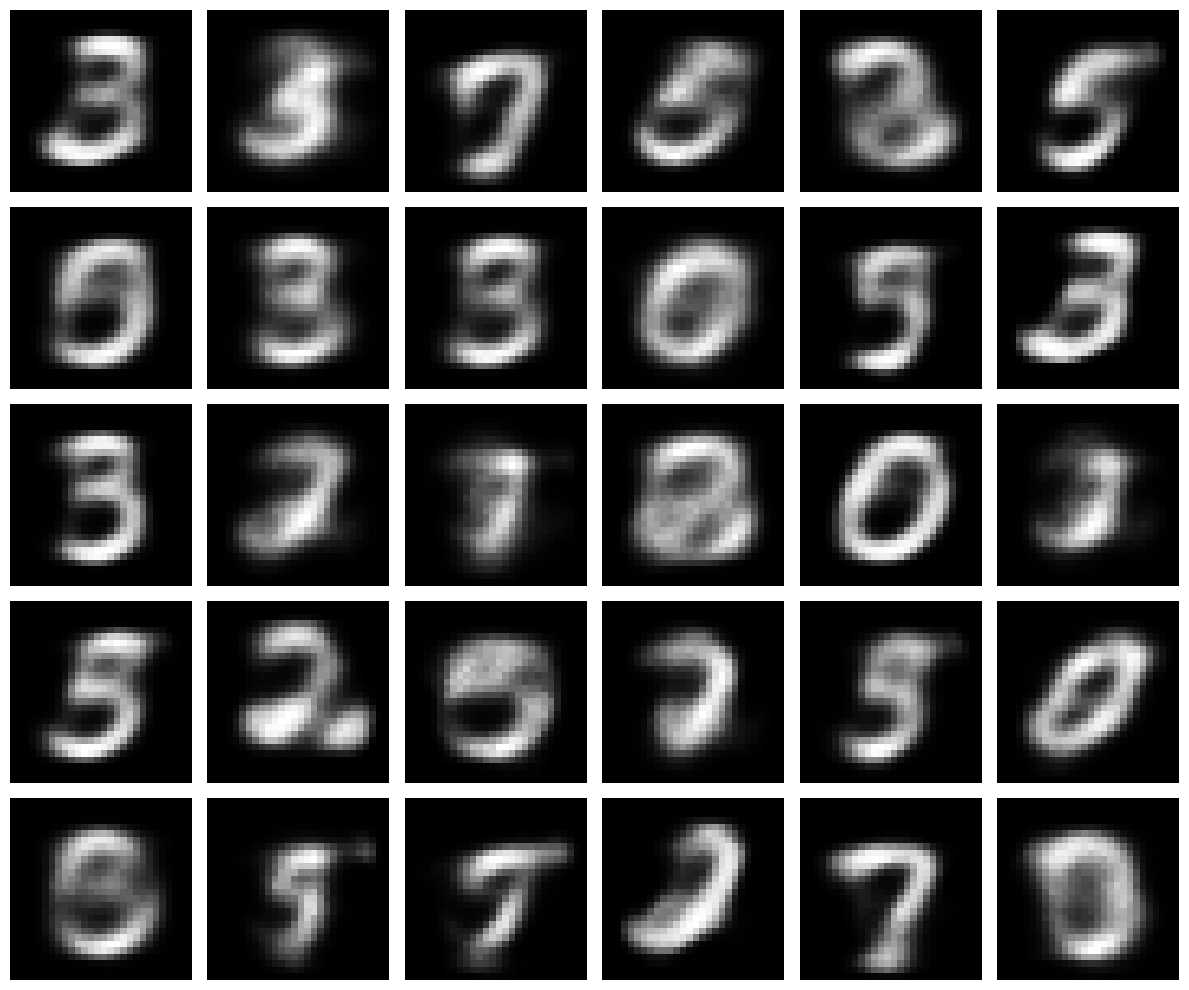

In [22]:
def generate_samples(model, num_samples):
    latent_dim = model.latent_dim
    z = tf.random.normal(shape=(num_samples, latent_dim))
    x_hat = model.decoder(z, training=False)
    images = tf.reshape(x_hat, (num_samples, 28, 28))

    return images

generated_images = generate_samples(model, 30)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, 6, figsize=(12, 10))
axes = axes.flatten()

for i, img in enumerate(generated_images):
    axes[i].imshow(img.numpy(), cmap="gray")
    axes[i].axis("off")

plt.tight_layout()
plt.show()


Train images pixels - Binary

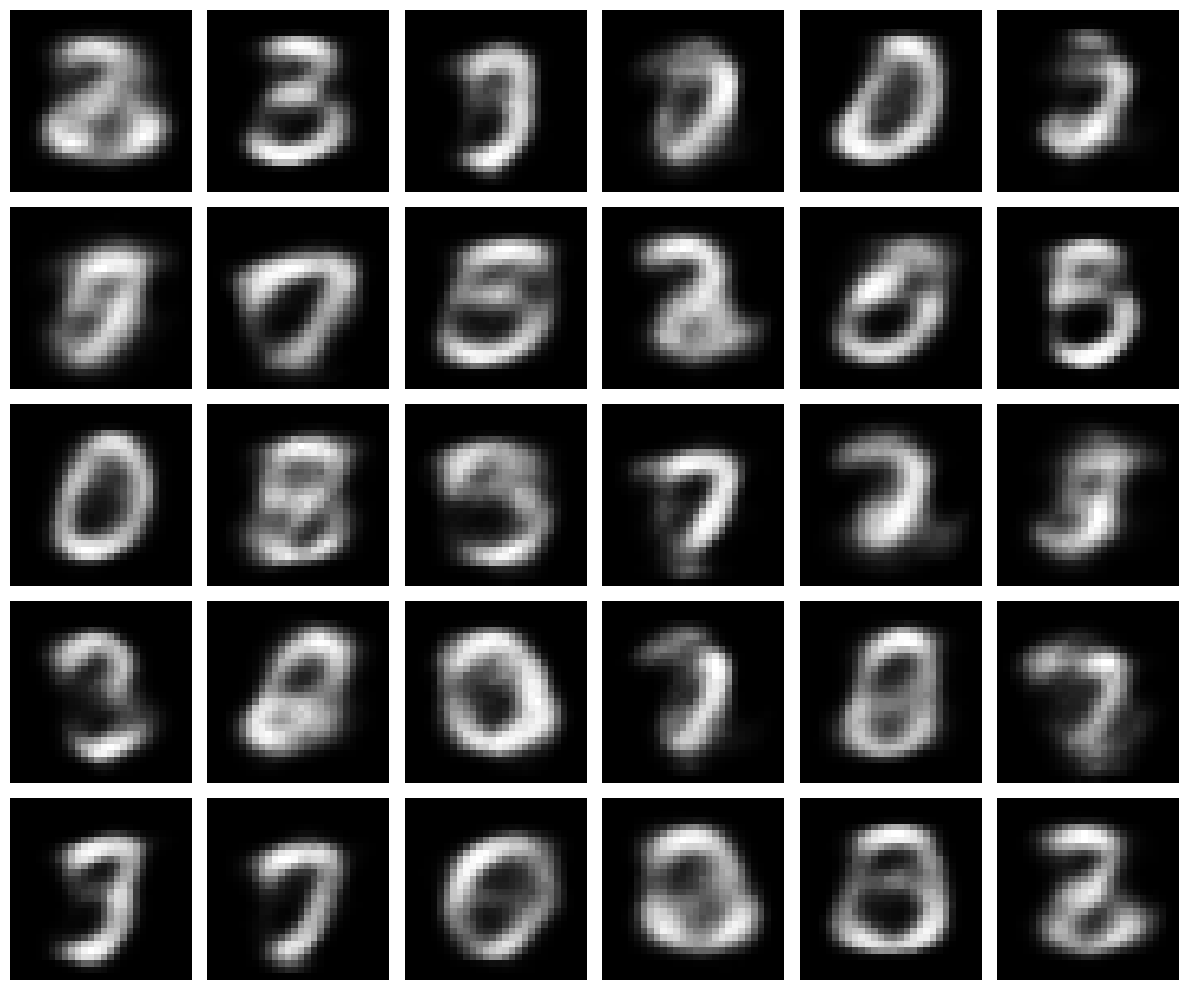

In [33]:
def generate_samples(model, num_samples):
    latent_dim = model.latent_dim
    z = tf.random.normal(shape=(num_samples, latent_dim))
    x_hat = model.decoder(z, training=False)
    images = tf.reshape(x_hat, (num_samples, 28, 28))

    return images

generated_images = generate_samples(model, 30)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, 6, figsize=(12, 10))
axes = axes.flatten()


for i, img in enumerate(generated_images):
    axes[i].imshow(img.numpy(), cmap="gray")
    axes[i].axis("off")

plt.tight_layout()
plt.show()